# 1. Predict equipment failure risk from sensor data

I use this notebook as the starting point of the series.

Each row is one machine record, and the target shows whether that machine failed. The job here is simple: train a readable baseline model, estimate failure risk from the available signals, and turn that score into a first action label.

I am not treating this as a production maintenance workflow. I am using it as a baseline to see which signals matter most in this dataset, how well a straightforward classifier separates failed from non failed records, and where a simple decision threshold starts to become useful.

# 2. Imports and config

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

TARGET = "fail"
RANDOM_STATE = 42
TEST_SIZE = 0.20

# 3. Load data

## 3.1 Data source

I use the Kaggle machine failure prediction dataset loaded at runtime.

For context, I also reviewed this public reference notebook:

- Stefan Clim
- Machine Failure Prediction using Sensor Data
- https://www.kaggle.com/code/climstefan/machine-failure-prediction-using-sensor-data/notebook

I use it only as background. The workflow, outputs, and decision framing in this notebook are my own.

In [2]:
def load_data(path: str, target: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    if target not in df.columns:
        raise ValueError(f"Missing target column: {target}")

    return df


DATA_PATH = "/kaggle/input/datasets/patimejia/machine-failure-prediction-using-sensor-stefan/data.csv"
df = load_data(DATA_PATH, TARGET)

display(df.head())

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


## 3.2: Clean data

In [3]:
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (943, 10)


# 4. Validate the dataset

In [4]:
def validate_data(df: pd.DataFrame, target: str) -> None:
    print("Shape:", df.shape)
    print("Duplicates:", df.duplicated().sum())

    print("\nMissing:")
    print(df.isnull().sum())

    print("\nDtypes:")
    print(df.dtypes)

    print("\nTarget:")
    print(df[target].value_counts())


validate_data(df, TARGET)

Shape: (943, 10)
Duplicates: 0

Missing:
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64

Dtypes:
footfall       int64
tempMode       int64
AQ             int64
USS            int64
CS             int64
VOC            int64
RP             int64
IP             int64
Temperature    int64
fail           int64
dtype: object

Target:
fail
0    550
1    393
Name: count, dtype: int64


# 5. Split features and target

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X:", X.shape)
print("y:", y.shape)

X: (943, 9)
y: (943,)


# 6. Train/test split

I keep the class balance roughly stable in train and test because the target is imbalanced.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (754, 9)
Test: (189, 9)


# 7. Model - RandomForest baseline

In [7]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', RandomForestClassifier(random_state=42))])

# 8. Evaluate

In [8]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

conf_matrix = confusion_matrix(y_test, y_pred)
test_accuracy = (y_pred == y_test).mean()
test_roc_auc = roc_auc_score(y_test, y_proba)

print("ROC AUC:", test_roc_auc)
print("Accuracy:", round(test_accuracy, 3))
print("\nConfusion:")
print(conf_matrix)
print("\nReport:")
print(classification_report(y_test, y_pred))

ROC AUC: 0.9764672036823935
Accuracy: 0.926

Confusion:
[[102   8]
 [  6  73]]

Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       110
           1       0.90      0.92      0.91        79

    accuracy                           0.93       189
   macro avg       0.92      0.93      0.92       189
weighted avg       0.93      0.93      0.93       189



# 9. Decision

In [9]:
def decision(probability):
    if probability >= 0.7:
        return "high", "inspect"
    if probability >= 0.4:
        return "medium", "check"
    return "low", "normal"


results = pd.DataFrame(
    {
        "row_id": y_test.index,
        "actual": y_test.to_numpy(),
        "pred": y_pred,
        "proba": y_proba,
    }
).reset_index(drop=True)

results[["risk", "action"]] = results["proba"].apply(
    lambda probability: pd.Series(decision(probability))
)

# 10. Sample decisions

In [10]:
display(results.head(10))

,row_id,actual,pred,proba,risk,action
0,309,1,1,0.99,high,inspect
1,142,0,0,0.08,low,normal
2,375,1,1,0.96,high,inspect
3,344,0,0,0.01,low,normal
4,58,1,1,0.98,high,inspect
5,480,0,0,0.02,low,normal
6,25,0,0,0.04,low,normal
7,53,0,0,0.11,low,normal
8,48,0,0,0.08,low,normal
9,15,0,0,0.10,low,normal


# 11. Feature importance

In [11]:
importances = pd.Series(
    pipeline.named_steps["model"].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(importances.to_frame("importance"))

,importance
VOC,0.411347
AQ,0.201431
USS,0.125332
CS,0.060186
footfall,0.051767
RP,0.050177
Temperature,0.048822
tempMode,0.027359
IP,0.023578


# 12 Artifact - Save decision output

In [12]:
results.to_csv("/kaggle/working/decision_results.csv", index=False)

# 13. Summary

I used a RandomForest baseline to estimate failure probability from the sensor table.

The main outputs in this notebook are:
- predicted class
- failure probability
- risk label
- suggested action

The evaluation above shows how this first pass behaves before I move to more operational framing in the next notebooks.

# 14. Score a sample machine record

In [13]:
def score_record(record: dict) -> pd.DataFrame:
    record_df = pd.DataFrame([record])
    pred = pipeline.predict(record_df)[0]
    proba = pipeline.predict_proba(record_df)[0, 1]
    risk, action = decision(proba)

    return pd.DataFrame([{
        "pred": pred,
        "proba": round(proba, 3),
        "risk": risk,
        "action": action
    }])

score_record({
    "footfall": 50,
    "tempMode": 3,
    "AQ": 5,
    "USS": 4,
    "CS": 2,
    "VOC": 10,
    "RP": 3,
    "IP": 2,
    "Temperature": 25
})

,pred,proba,risk,action
0,1,0.57,medium,check


# 15. Compare a lower risk and higher risk profile

In [14]:
lower_risk_profile = {
    "footfall": 0,
    "tempMode": 1,
    "AQ": 1,
    "USS": 1,
    "CS": 1,
    "VOC": 1,
    "RP": 1,
    "IP": 1,
    "Temperature": 20
}

higher_risk_profile = {
    "footfall": 700,
    "tempMode": 7,
    "AQ": 7,
    "USS": 7,
    "CS": 7,
    "VOC": 80,
    "RP": 7,
    "IP": 7,
    "Temperature": 80
}

profile_results = pd.concat(
    [
        score_record(lower_risk_profile).assign(profile="lower_risk"),
        score_record(higher_risk_profile).assign(profile="higher_risk")
    ],
    ignore_index=True
)

display(profile_results[["profile", "pred", "proba", "risk", "action"]])

,profile,pred,proba,risk,action
0,lower_risk,0,0.45,medium,check
1,higher_risk,0,0.38,low,normal


# 16. Decision policy - threshold comparison

In [15]:
def evaluate_threshold(threshold: float) -> dict:
    pred_t = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred_t)

    tn, fp, fn, tp = cm.ravel()

    return {
        "threshold": threshold,
        "accuracy": round((tp + tn) / cm.sum(), 3),
        "false_alarms": int(fp),
        "missed_failures": int(fn)
    }

threshold_table = pd.DataFrame([
    evaluate_threshold(0.4),
    evaluate_threshold(0.5),
    evaluate_threshold(0.6),
    evaluate_threshold(0.7)
])

display(threshold_table)

,threshold,accuracy,false_alarms,missed_failures
0,0.4,0.905,13,5
1,0.5,0.931,8,5
2,0.6,0.931,5,8
3,0.7,0.899,3,16


# 17. How threshold choice changes missed failures and false alarms

In [16]:
fewest_missed = threshold_table.sort_values("missed_failures").iloc[0]
fewest_false_alarms = threshold_table.sort_values("false_alarms").iloc[0]

insight = pd.DataFrame([
    {
        "strategy": "fewest_missed_failures",
        "threshold": fewest_missed["threshold"],
        "missed_failures": fewest_missed["missed_failures"],
        "false_alarms": fewest_missed["false_alarms"]
    },
    {
        "strategy": "fewest_false_alarms",
        "threshold": fewest_false_alarms["threshold"],
        "missed_failures": fewest_false_alarms["missed_failures"],
        "false_alarms": fewest_false_alarms["false_alarms"]
    }
])

display(insight)

,strategy,threshold,missed_failures,false_alarms
0,fewest_missed_failures,0.4,5.0,13.0
1,fewest_false_alarms,0.7,16.0,3.0


# 18. What the model relied on and how thresholds shift errors

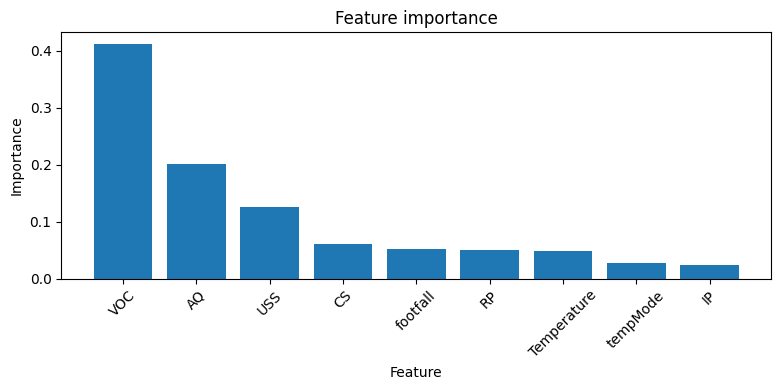

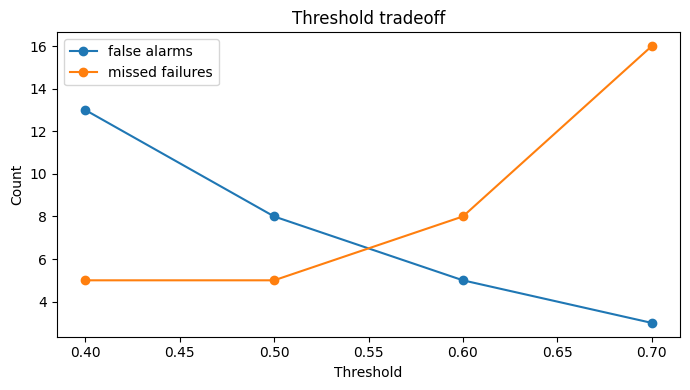

In [17]:
# Feature importance
plt.figure(figsize=(8, 4))
plt.bar(importances.index, importances.values)
plt.title("Feature importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Threshold tradeoff
plt.figure(figsize=(7, 4))
plt.plot(threshold_table["threshold"], threshold_table["false_alarms"], marker="o", label="false alarms")
plt.plot(threshold_table["threshold"], threshold_table["missed_failures"], marker="o", label="missed failures")
plt.title("Threshold tradeoff")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 19. What this baseline is useful for

This notebook is useful as a first classification pass on the sensor table.

It gives me a readable baseline model, estimated failure probabilities, simple risk labels, and a direct threshold comparison. That is enough to see whether the signal set carries usable separation and whether the predicted scores can support a basic decision rule.

What it does not solve is queue ranking, inspection capacity, exact failure timing, or a formal operating threshold chosen from a validation policy. I handle those parts more directly in the later notebooks.

# 20. Column notes

These descriptions are practical readings of the column names, not official hardware definitions.

- **footfall:** nearby movement or activity count
- **tempMode:** temperature related operating mode
- **AQ:** air quality reading
- **USS:** ultrasonic sensor reading
- **CS:** current related sensor reading
- **VOC:** volatile organic compound reading
- **RP:** motion or rotation related signal
- **IP:** pressure related signal
- **Temperature:** measured temperature
- **fail:** 0 means no failure, 1 means failure